# Evaluation of LLM model for member names and task descriptions extraction

In this notebook, different evaluation metrics are calculated to assess the LLM model's performance. First, roster and raw text names are compared between the model outputs and the gold standard — a JSON file of 14 manually annotated teams. Second, task descriptions are compared between two JSON files. Results from three prompting rounds are evaluated.

The model shows excellent performance in extracting member names from text (average F1 score close to 1), while its task descriptions are also fairly accurate (average cosine similarity score around 0.8). However, there are differences between teams, and the model performs poorly when attributions are listed in tables. These variations show the importance of exploring how the formatting of attribution web pages affects model performance. The findings from this notebook can help us improve the model and determine which types of attribution formats work well, ultimately excluding teams with problematic formats when prompting the model.

Since we are working with small samples (14 annotated teams, 3 rounds each), bootstrapping could make this evaluation much clearer and more statistically robust, allowing us to calculate confidence intervals for measures such as cosine similarity means. This should be considered in the future stages of the project.

Note: Comments in the notebook are related only to August Mac Studio results and analysis should be repeated with the Jean Zay results where only one prompting round is needed (results are almost completely the same in all 3 rounds).

In [1]:
import pandas as pd
from rapidfuzz import fuzz
import unicodedata
import json
from collections import Counter, defaultdict
import re
from rouge_score import rouge_scorer
import time
import requests
import os
from statistics import mean, stdev
import math
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [2]:
# Plot Configuration

# Color palette
sns.set_palette("deep")

# Styles for seaborn
sns.set_context("notebook", rc={
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

# Styles for matplotlib
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'figure.figsize': (8, 6),
    'axes.titlepad': 20,   
    'axes.labelpad': 20,  
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.titlepad": 20,     
    "axes.labelpad": 20 
})

## 1. Data

In [5]:
# model_path = "../data/attributions/2022_attributions/llm_json_outputs/14_teams_single_name_prompting_3_rounds.json"
# model_path = "../data/attributions/2022_attributions/llm_json_outputs/14_teams_jean_zay_results.json"
model_path = "../data/attributions/2022_attributions/llm_extraction_outputs/14_teams_jean_zay_results_with_username.json"
gold_path = "../data/attributions/2022_attributions/manual_annotation/14_test_teams.json"

with open(model_path, "r", encoding="utf-8") as f:
    model_outputs_raw_json = json.load(f)

with open(gold_path, "r", encoding="utf-8") as f:
    gold_standard_raw_json = json.load(f)

In [5]:
# model_outputs_raw_json

In [6]:
# gold_standard_raw_json

In [6]:
# To easily access teams or rounds (by name and not index) - remove the big list
model_outputs = {}
for team_obj in model_outputs_raw_json:
    model_outputs.update(team_obj)

gold_standard = {}
for team_obj in gold_standard_raw_json:
    gold_standard.update(team_obj)

In [7]:
# Sort teams and roster names by alphabetical order - just to check but we will not rely on name order while fuzzy matching beacause some names might be missing or hallucinated

model_outputs = dict(sorted(model_outputs.items(), key=lambda x: x[0].lower()))
gold_standard = dict(sorted(gold_standard.items(), key=lambda x: x[0].lower()))

# For gold_standard: members are in a list directly
for team, members in gold_standard.items():
    gold_standard[team] = sorted(members, key=lambda x: x.get("RosterName", "").lower())

# For model_outputs: members are nested under rounds
for team, rounds in model_outputs.items():
    for round_name, members in rounds.items():
        model_outputs[team][round_name] = sorted(members, key=lambda x: x.get("RosterName", "").lower())

In [8]:
# Example how to access teams and members
team_name = "Aalto-Helsinki"
round1_output = model_outputs[team_name]["Round1"] 
gold_entries = gold_standard[team_name]  
round1_output_person_0 = round1_output[0]
# round1_output_person_0["RosterName"]

In [47]:
# model_outputs

In [9]:
# Check if there are any RawTextName or RosterName duplicates within a team and a round 

def check_name_duplicates(model_outputs):
    for team, rounds in model_outputs.items():
        for round_name, predictions in rounds.items():
            roster_names = [entry.get("RosterName", "") for entry in predictions]
            rawtext_names = [entry.get("RawTextName", "") for entry in predictions]

            roster_duplicates = [
                name for name, count in Counter(roster_names).items()
                if count > 1 and name
            ]
            rawtext_duplicates = [
                name for name, count in Counter(rawtext_names).items()
                if count > 1 and name
            ]

            if roster_duplicates or rawtext_duplicates:
                print(f"Duplicates found in team '{team}', round '{round_name}':")
                if roster_duplicates:
                    print(f"  RosterName duplicates: {roster_duplicates}")
                if rawtext_duplicates:
                    print(f"  RawTextName duplicates: {rawtext_duplicates}")
            # else:
            #     print(f"No duplicates found in team '{team}', round '{round_name}'.")

check_name_duplicates(model_outputs)

Duplicates found in team 'Technion-Israel', round 'Round1':
  RosterName duplicates: ['Noa Ben David', 'Shira']
Duplicates found in team 'Technion-Israel', round 'Round2':
  RosterName duplicates: ['Irina Bulushev', 'Mattan Galili', 'Shira']
Duplicates found in team 'Technion-Israel', round 'Round3':
  RosterName duplicates: ['Maayan Bibas', 'Yasmin Abu-Ashour']
Duplicates found in team 'TU_Braunschweig', round 'Round1':
  RosterName duplicates: ['Benjamin Harder', 'Fabienne Spang']
Duplicates found in team 'TU_Braunschweig', round 'Round2':
  RosterName duplicates: ['Benjamin Harder', 'Fabienne Spang']
Duplicates found in team 'TU_Braunschweig', round 'Round3':
  RosterName duplicates: ['Benjamin Harder', 'Fabienne Spang', 'Frauke Drobek', 'Sina Huxhagen']


Since there are no name duplicates in model outputs (e.g. the model outputs the same RosterName twice for one team in the same round), we can proceed with the following evaluation metrics. There are no duplicates because we are evaluating outputs of the model that was prompted name by name. If we were to evaluate the outputs of the model prompted by batches of roster names at a time, there might be some duplicates that would need to be dealth with before evaluation (e.g. keep the non null fields, keep a union of TaksDescription). This should be considered in the future stages of the project.

## 2. Roster and Raw Text Name Metrics

Member names (`RosterName` and `RawTextName`) in both the model outputs and the manually annotated dataset are normalized (converted to empty string if they are null, stripped of trailing or leading blank spaces, converted to ASCII and lowercase). The goal is to fuzzy match model's normalized names to the corresponding ones in the gold standard. The model's extracted name is considered correct if it fuzzy matches the one in the gold standard. The fuzzy matching is first done by full name, reverse full name, and then first and last part of the name individually. The fuzzy matching is done because model's name extraction does not need to be perfect since the RosterName and RawTextName will be combined into one field with fuzzy matching in the later steps of the project (before giving the final dataset to the BERT model for task classification). The important part is to evaluate model's tendencies to hallucinate names whose fuzzy matches are not present in the gold standard, or to omit some names.

Unmatched predictions (**false  positives**) represent the hallucinated names. Unmatched names from the gold standard (**false negatives**) represent the names that the model omitted (failed to extract for RawTextName, or is missing an output for a prompted RosterName). Matched predictions (**true positives**) include cases where a name is null in both the model output and the gold standard, as well as cases where a non-null name is present in both and is matched fuzzily. Thus, true negatives are not defined as all matches between names (null or non-null) are considered as true positives.

Therefore, the selected evaluation metrics are:
- **Precision** - measure of hallucinations (i.e., how many of the names the model extracted were actually correct?)
- **Recall** - measure of omissions (i.e., how many of the actual correct names did the model find?) 
- **F1 score** - harmonic mean of precision and recall

A correct extraction also includes cases where the name is null in both the model output and the gold standard.

These metrics are computed for both `RosterName` and `RawTextName`.

In [12]:
# Name normalization and fuzzy matching

def normalize_text(text):
    if not text or not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    return " ".join(text.lower().strip().split())

def fuzzy_match_name(predicted, gold, threshold = 80):
    predicted_norm = normalize_text(predicted)
    gold_norm = normalize_text(gold)

    # Full name 
    full_score = fuzz.token_sort_ratio(predicted_norm, gold_norm)

    # Reverse name 
    predicted_rev = " ".join(predicted_norm.split()[::-1])
    reverse_score = fuzz.token_sort_ratio(predicted_rev, gold_norm)

    # First/last name (first and last word)
    predicted_parts = predicted_norm.split()
    gold_parts = gold_norm.split()
    first_last_score = 0
    if predicted_parts and gold_parts:
        first_score = fuzz.ratio(predicted_parts[0], gold_parts[0])
        last_score = fuzz.ratio(predicted_parts[-1], gold_parts[-1])
        first_last_score = max(first_score, last_score)

    return max(full_score, reverse_score, first_last_score) >= threshold


In [50]:
# Example of running the function
fuzzy_match_name(round1_output[0]["RosterName"], gold_entries[0]["RosterName"])

False

In [13]:
# Compute Precision, Recall, F1, and also return unmatched names for analysis
# This function compares the list of predicted names against the list gold standard names using fuzzy matching previously defined

def compute_name_metrics(pred_names, gold_names, threshold=80):

    pred_names = [normalize_text(n) for n in pred_names]
    gold_names = [normalize_text(n) for n in gold_names]

    # So matching is done only once for each name
    matched_gold = set()
    matched_pred = set()

    for i, pred in enumerate(pred_names):
        for j, gold in enumerate(gold_names):
            if j in matched_gold:
                continue #skip already matched gold names
            if not pred and not gold:
                matched_pred.add(i)
                matched_gold.add(j)
                break 
            if pred and gold and fuzzy_match_name(pred, gold, threshold):
                matched_pred.add(i)
                matched_gold.add(j)
                break

    # Calculate metrics
    TP = len(matched_pred) # Num of correct predictions (matched null or non-null names)
    FP = len([p for i, p in enumerate(pred_names) if i not in matched_pred and p]) # Num of hallucinated names
    FN = len(gold_names) - len(matched_gold) # Num of omitted names

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # Collect unmatched names
    hallucinated_names = [pred_names[i] for i in range(len(pred_names)) if i not in matched_pred and pred_names[i]] # unmatched names from prediction name list
    omitted_names = [gold_names[j] for j in range(len(gold_names)) if j not in matched_gold] # unmatched names from gold standard name list

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "unmatched_pred": hallucinated_names,
        "unmatched_gold": omitted_names
    }

In [52]:
# Loop over teams & rounds and compute metrics for names

# Initialize a dictionary to store metrics per round, add more rounds if needed
round_metrics = {"Round1": [], "Round2": [], "Round3": []} 

# Collect mismatched names for further analysis
round_mismatches = {"Round1": [], "Round2": [], "Round3": []}

for team, rounds in model_outputs.items():

    gold_entries = gold_standard[team]
    gold_roster_names = [item.get("RosterName", "") for item in gold_entries] #lists of names to be used as arguments in compute_name_metrics
    gold_raw_names = [item.get("RawTextName", "") for item in gold_entries]

    for round_name, predictions in rounds.items():
        pred_roster_names = [item.get("RosterName", "") for item in predictions]
        pred_raw_names = [item.get("RawTextName", "") for item in predictions]

        # Compute metrics for RosterName and RawTextName
        roster_metrics = compute_name_metrics(pred_roster_names, gold_roster_names)
        raw_metrics = compute_name_metrics(pred_raw_names, gold_raw_names)

        round_metrics[round_name].append({
            "team": team,
            "roster_precision": roster_metrics["precision"],
            "roster_recall": roster_metrics["recall"],
            "roster_f1": roster_metrics["f1"],
            "raw_precision": raw_metrics["precision"],
            "raw_recall": raw_metrics["recall"],
            "raw_f1": raw_metrics["f1"]
        })

        # Store mismatches if any
        if roster_metrics["unmatched_pred"] or roster_metrics["unmatched_gold"] or \
           raw_metrics["unmatched_pred"] or raw_metrics["unmatched_gold"]:
            round_mismatches[round_name].append({
                "team": team,
                "roster_unmatched_pred": roster_metrics["unmatched_pred"],
                "roster_unmatched_gold": roster_metrics["unmatched_gold"],
                "raw_unmatched_pred": raw_metrics["unmatched_pred"],
                "raw_unmatched_gold": raw_metrics["unmatched_gold"]
            })

# Aggregate per round for all teams - code that works when there is only one round

summary = {}
for round_name, team_scores in round_metrics.items():
    # Only calculate metrics if there are scores to average
    if team_scores: 
        teams_evaluated = len(team_scores)
        
        # Average metrics across all teams for each round
        avg_roster_precision = sum(s["roster_precision"] for s in team_scores) / teams_evaluated
        avg_roster_recall = sum(s["roster_recall"] for s in team_scores) / teams_evaluated
        avg_roster_f1 = sum(s["roster_f1"] for s in team_scores) / teams_evaluated
    
        avg_raw_precision = sum(s["raw_precision"] for s in team_scores) / teams_evaluated
        avg_raw_recall = sum(s["raw_recall"] for s in team_scores) / teams_evaluated
        avg_raw_f1 = sum(s["raw_f1"] for s in team_scores) / teams_evaluated

        summary[round_name] = {
            "teams_evaluated": teams_evaluated,
            "avg_roster_precision": avg_roster_precision,
            "avg_roster_recall": avg_roster_recall,
            "avg_roster_f1": avg_roster_f1,
            "avg_raw_precision": avg_raw_precision,
            "avg_raw_recall": avg_raw_recall,
            "avg_raw_f1": avg_raw_f1
        }
    else:
        # Populate with zeros if the round was skipped
        summary[round_name] = {
            "teams_evaluated": 0,
            "avg_roster_precision": 0.0,
            "avg_roster_recall": 0.0,
            "avg_roster_f1": 0.0,
            "avg_raw_precision": 0.0,
            "avg_raw_recall": 0.0,
            "avg_raw_f1": 0.0
        }

# Print the summary of metrics per round
print("\nPer Round Summary:")
for round_name, stats in summary.items():
    print(f"\n{round_name} (based on {stats['teams_evaluated']} teams):")
    print(f"  RosterName - Precision: {stats['avg_roster_precision']:.3f}, Recall: {stats['avg_roster_recall']:.3f}, F1: {stats['avg_roster_f1']:.3f}")
    print(f"  RawTextName - Precision: {stats['avg_raw_precision']:.3f}, Recall: {stats['avg_raw_recall']:.3f}, F1: {stats['avg_raw_f1']:.3f}")


Per Round Summary:

Round1 (based on 14 teams):
  RosterName - Precision: 1.000, Recall: 1.000, F1: 1.000
  RawTextName - Precision: 0.995, Recall: 0.992, F1: 0.993

Round2 (based on 0 teams):
  RosterName - Precision: 0.000, Recall: 0.000, F1: 0.000
  RawTextName - Precision: 0.000, Recall: 0.000, F1: 0.000

Round3 (based on 0 teams):
  RosterName - Precision: 0.000, Recall: 0.000, F1: 0.000
  RawTextName - Precision: 0.000, Recall: 0.000, F1: 0.000


August results for 3 rounds: Precision is 1 for both `RosterName` and `RawTextName`, meaning that there are no hallucinated names in any of the rounds. The recall for `RawTextName` is 0.993 across all three rounds, meaning that some names present in the gold standard were not matched with the model’s raw text name outputs. There might be a big misalignment between spelling of the names, or these names have been returned as null in the model but are present in the gold standard. Since we saved these names in the return values of the `compute_name_metrics` function, we can print them to see what the misalignment between model outputs and gold standard is.

In [53]:
print("\nMismatched Normalized Names (Hallucinated or Omitted):")
for round_name, mismatches in round_mismatches.items():
    if not mismatches:
        print(f"{round_name}: No mismatches.")
        continue

    print(f"\n{round_name}:")
    for entry in mismatches:
        print(f"  Team: {entry['team']}")
        if entry["roster_unmatched_pred"]:
            print("    RosterName - Unmatched From Predictions:", entry["roster_unmatched_pred"])
        if entry["roster_unmatched_gold"]:
            print("    RosterName - Unmatched From Gold:", entry["roster_unmatched_gold"])
        if entry["raw_unmatched_pred"]:
            print("    RawTextName - Unmatched From Predictions:", entry["raw_unmatched_pred"])
        if entry["raw_unmatched_gold"]:
            print("    RawTextName - Unmatched From Gold:", entry["raw_unmatched_gold"])


Mismatched Normalized Names (Hallucinated or Omitted):

Round1:
  Team: Cambridge
    RawTextName - Unmatched From Gold: ['anthony phung']
  Team: Freiburg
    RawTextName - Unmatched From Predictions: ['anne zemella']
    RawTextName - Unmatched From Gold: ['']
Round2: No mismatches.
Round3: No mismatches.


The normalized versions of unmatched names from the gold standard are checked manually. Their RawTextName value is null in the model output. Since their raw text names differ quite a bit from their roster names, the LLM model did not succeed in extracting them or their task descriptions.

## 3. Tasks Description Metrics

Evaluating the task description extraction is a bit more complicated because descriptions cannot just be fuzzy matched. Sometimes, the model and the gold standard express the same idea using slightly different wording in `TasksDescription`. For example, the `TasksDescription` value from the gold standard could be: “for help with project ideation and planning,” while the same value in the model output might be: “Thank you \<name\> for help with project ideation and planning.” Both versions are valid since both contain information about the tasks performed. Therefore, the meaning of the sentences can also be important, not just word overlap.

It is also important that different word order in two task descriptions should not matter, as long no information is omitted or hallucinated. For this reason, the  ROUGE-L scoring method that looks for the Longest Common Subsequence (LCS) and preserves word order may not be the best evaluation method, but, as it gives us precision and recall, it is still considered here.

Therefore, the chosen scoring methods are:
- **Jaccard Similarity** - treats task descriptions as "bags of words", where order and repetition of words is not important
- **ROUGE-L (LCS)** - looks for the Longest Common Subsequence and provides precision (LCS length / number of words in the predicted text), recall (LCS length / number of words in the gold standard text), and the F1 score
- **Sentence-BERT Cosine Similarity** - measures how similar two sentences are in meaning 

The first and the third scoring methods provide similarity scores between task descriptions. The Jaccard score ranges from 0 to 1, while cosine similarity theoretically ranges from -1 to 1, but in Sentence-BERT the typical range is also 0 to 1. For example, this score is 1 between two empty strings (when `TaskDescription` is null in both the model output and gold standard).

Task descriptions should be normalized first, in the same way as member names.

In [10]:
# Helper function to compute standard error
def compute_se(values):
    if len(values) <= 1:
        return 0.0
    mean = sum(values) / len(values)
    variance = sum((x - mean) ** 2 for x in values) / (len(values) - 1)
    return math.sqrt(variance) / math.sqrt(len(values))

## 3.1 Jaccard Similarity

In [55]:
def jaccard_similarity(str1, str2):
    set1 = set(str1.split())
    set2 = set(str2.split())
    if not set1 and not set2:
        return 1.0
    if not set1 or not set2:
        return 0.0
    return len(set1 & set2) / len(set1 | set2)

team_round_scores = defaultdict(lambda: defaultdict(list))  # team -> round -> [scores]
round_scores = defaultdict(list)  # round -> [team averages]

# Compute metrics
for team, rounds in model_outputs.items():
    if team not in gold_standard:
        continue

    gold_entries = gold_standard[team]
    gold_tasks = [normalize_text(entry.get("TasksDescription", "")) for entry in gold_entries]

    for round_name, predictions in rounds.items():
        scores = []
        for i, member in enumerate(predictions):
            pred_tasks = normalize_text(member.get("TasksDescription", ""))
            gold_tasks_text = gold_tasks[i] if i < len(gold_tasks) else ""
            score = jaccard_similarity(pred_tasks, gold_tasks_text)
            scores.append(score)

        if scores:
            team_round_scores[team][round_name] = scores
            round_scores[round_name].append(sum(scores) / len(scores))  # per-team average

# Print per team per round
print("Average Jaccard Similarity per Team per Round:\n")
for team, rounds in sorted(team_round_scores.items()):
    print(f"Team: {team}")
    for round_name in ["Round1", "Round2", "Round3"]:
        scores = rounds.get(round_name)
        if scores:
            avg = sum(scores) / len(scores)
            se = compute_se(scores)
            print(f"  {round_name}: {avg:.3f} ± {se:.3f}")
        else:
            print(f"  {round_name}: No data")
    print()

Average Jaccard Similarity per Team per Round:

Team: Aalto-Helsinki
  Round1: 0.912 ± 0.016
  Round2: No data
  Round3: No data

Team: Aboa
  Round1: 0.813 ± 0.037
  Round2: No data
  Round3: No data

Team: BostonU_HW
  Round1: 1.000 ± 0.000
  Round2: No data
  Round3: No data

Team: CPU_Nanjing
  Round1: 0.621 ± 0.035
  Round2: No data
  Round3: No data

Team: CSMU_Taiwan
  Round1: 0.759 ± 0.022
  Round2: No data
  Round3: No data

Team: Cambridge
  Round1: 0.649 ± 0.052
  Round2: No data
  Round3: No data

Team: Freiburg
  Round1: 0.325 ± 0.092
  Round2: No data
  Round3: No data

Team: Goettingen
  Round1: 0.823 ± 0.073
  Round2: No data
  Round3: No data

Team: ICT-Mumbai
  Round1: 0.814 ± 0.043
  Round2: No data
  Round3: No data

Team: Montpellier
  Round1: 0.915 ± 0.057
  Round2: No data
  Round3: No data

Team: Sogang_Korea
  Round1: 0.706 ± 0.100
  Round2: No data
  Round3: No data

Team: TU_Braunschweig
  Round1: 0.744 ± 0.060
  Round2: No data
  Round3: No data

Team: Techn

In [56]:
# Print Jaccard per round with SE
print("Average Jaccard Similarity per Round (Averaged Across Teams):")
for round_name in ["Round1", "Round2", "Round3"]:
    team_avgs = round_scores.get(round_name)
    if team_avgs:
        avg = sum(team_avgs) / len(team_avgs)
        se = compute_se(team_avgs)
        print(f"  {round_name}: {avg:.3f} ± {se:.3f}")
    else:
        print(f"  {round_name}: No data")

Average Jaccard Similarity per Round (Averaged Across Teams):
  Round1: 0.757 ± 0.046
  Round2: No data
  Round3: No data


## 3.2 ROUGE-L (Longest Common Subsequence)

In [57]:
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_rouge_l(pred, gold):
    pred = normalize_text(pred)
    gold = normalize_text(gold)

    if not pred and not gold:
        return {"precision": 1.0, "recall": 1.0, "f1": 1.0}
    if not pred or not gold:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    scores = scorer.score(gold, pred)["rougeL"]
    return {"precision": scores.precision, "recall": scores.recall, "f1": scores.fmeasure}

# Containers
team_round_metrics = defaultdict(lambda: defaultdict(list))  
round_metrics = defaultdict(list) 

# Compute metrics
for team, rounds in model_outputs.items():
    if team not in gold_standard:
        continue

    gold_entries = gold_standard[team]
    gold_tasks = [m.get("TasksDescription", "") for m in gold_entries]

    for round_name, predictions in rounds.items():
        for i, member in enumerate(predictions):
            pred_tasks = member.get("TasksDescription", "")
            gold_tasks_text = gold_tasks[i] if i < len(gold_tasks) else ""
            scores = compute_rouge_l(pred_tasks, gold_tasks_text)

            team_round_metrics[team][round_name].append(scores)
            round_metrics[round_name].append(scores)

# Print per team per round 
print("\nROUGE-L Metrics Per Team per Round:")
for team, round_data in team_round_metrics.items():
    print(f"\nTeam: {team}")
    for round_name, scores in round_data.items():
        if not scores:
            continue
        precisions = [s["precision"] for s in scores]
        recalls = [s["recall"] for s in scores]
        f1s = [s["f1"] for s in scores]

        avg_p, se_p = sum(precisions) / len(precisions), compute_se(precisions)
        avg_r, se_r = sum(recalls) / len(recalls), compute_se(recalls)
        avg_f1, se_f1 = sum(f1s) / len(f1s), compute_se(f1s)

        # With standard error:
        # print(f"  {round_name}: Precision={avg_p:.3f} ± {se_p:.3f}, Recall={avg_r:.3f} ± {se_r:.3f}, F1={avg_f1:.3f} ± {se_f1:.3f}")
        print(f"  {round_name}: Precision={avg_p:.3f}, Recall={avg_r:.3f}, F1={avg_f1:.3f}")


ROUGE-L Metrics Per Team per Round:

Team: Aalto-Helsinki
  Round1: Precision=0.970, Recall=0.934, F1=0.948

Team: Aboa
  Round1: Precision=1.000, Recall=0.782, F1=0.868

Team: BostonU_HW
  Round1: Precision=1.000, Recall=1.000, F1=1.000

Team: Cambridge
  Round1: Precision=0.669, Recall=0.919, F1=0.751

Team: CPU_Nanjing
  Round1: Precision=0.855, Recall=0.683, F1=0.730

Team: CSMU_Taiwan
  Round1: Precision=1.000, Recall=1.000, F1=1.000

Team: Freiburg
  Round1: Precision=0.926, Recall=0.341, F1=0.421

Team: Goettingen
  Round1: Precision=0.705, Recall=0.607, F1=0.625

Team: ICT-Mumbai
  Round1: Precision=0.956, Recall=0.810, F1=0.861

Team: Montpellier
  Round1: Precision=1.000, Recall=0.898, F1=0.931

Team: Sogang_Korea
  Round1: Precision=0.714, Recall=0.703, F1=0.708

Team: Technion-Israel
  Round1: Precision=0.959, Recall=0.924, F1=0.917

Team: TU_Braunschweig
  Round1: Precision=0.961, Recall=0.919, F1=0.934

Team: UPNAvarra_Spain
  Round1: Precision=0.855, Recall=0.698, F1=0.

In [58]:
# Print average ROUGE-L per round with SE 
print("\nROUGE-L Average Metrics per Round:")
for round_name, scores in round_metrics.items():
    if not scores:
        continue
    precisions = [s["precision"] for s in scores]
    recalls = [s["recall"] for s in scores]
    f1s = [s["f1"] for s in scores]

    avg_p, se_p = sum(precisions) / len(precisions), compute_se(precisions)
    avg_r, se_r = sum(recalls) / len(recalls), compute_se(recalls)
    avg_f1, se_f1 = sum(f1s) / len(f1s), compute_se(f1s)

    print(f"  {round_name}: Precision={avg_p:.3f} ± {se_p:.3f}, Recall={avg_r:.3f} ± {se_r:.3f}, F1={avg_f1:.3f} ± {se_f1:.3f}")


ROUGE-L Average Metrics per Round:
  Round1: Precision=0.893 ± 0.015, Recall=0.802 ± 0.018, F1=0.814 ± 0.016



For all rounds, the Rouge-L precision and recall are high. There are differences between teams. Teams with well-structured attribution pages (e.g., having member names as subtitles and their tasks as paragraphs below the subtitles) have high metric values, around 0.8 to 1. Teams that have less defined page structures (e.g., mentioning members a few times throughout the raw text) or teams that structure their attributions in tables have lower precision and recall. For example, a team whose text is unreadable because it was incorrectly extracted from a table has `TasksDescription` set to null in the gold standard. However, the LLM still tries to read the unreadable table and sometimes doesn't output a null `TasksDescription`. Precision and recall for such a team are significantly lower than for other teams, around 0.3. In future steps of the project, teams with table structures should be considered separately, possibly by passing their HTML attributions instead of the raw texts to the LLM.

## 3.3 Sentence-BERT Cosine Similarity

To run the code below that uses the Hugging Face Inference API instead of loading model directly from transformers, make sure to create an `HF_TOKEN` environment variable (not pushed to this repository). Your Hugging Face token must have permission to access the `sentence-transformers` models. The .env file in the root of the repository should look like this:

```
HF_TOKEN=your_hf_token
```

Look into how to run it without using the API, since it is slow and requires a stable internet connection.


In [59]:
'''
The code bellow loads model directly.
But, it outputs AttributeError: module 'torch' has no attribute 'uint64'.
Check different torch version or use transformers library to load the model.
'''

# from transformers import AutoTokenizer, AutoModel

# tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
# model = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

"\nThe code bellow loads model directly.\nBut, it outputs AttributeError: module 'torch' has no attribute 'uint64'.\nCheck different torch version or use transformers library to load the model.\n"

In [60]:
'''
 Other option is to use the Hugging Face Inference API as shown below, 
 but it requires an API Hugging Face token and a stable internet connection.
 This code is using a token stored in an environment variable.
 It is an example of how to use the API to compute sentence similarity, while the next code cell is using the API for our task.
'''
# load_dotenv() 
# hf_token = os.getenv('HF_TOKEN')

# API_URL = "https://router.huggingface.co/hf-inference/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/pipeline/sentence-similarity"
# headers = {
#     "Authorization": f"Bearer {hf_token}",
# }

# def query(payload):
#     response = requests.post(API_URL, headers=headers, json=payload)
#     return response.json()

# output = query({
#     "inputs": {
#     "source_sentence": "That is a happy person",
#     "sentences": [
#         "That is a happy dog",
#         "That is a very happy person",
#         "Today is a sunny day"
#     ]
# },
# })

# print(output)

'\n Other option is to use the Hugging Face Inference API as shown below, \n but it requires an API Hugging Face token and a stable internet connection.\n This code is using a token stored in an environment variable.\n It is an example of how to use the API to compute sentence similarity, while the next code cell is using the API for our task.\n'

In [14]:
# Hugging Face Inference API for computing cosine similarity between TasksDescription fields

load_dotenv(override=True) # so the token is taken from the .env file and not some shell variable
hf_token = os.getenv('HF_TOKEN')

API_URL = "https://router.huggingface.co/hf-inference/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/pipeline/sentence-similarity"
HEADERS = {
    "Authorization": f"Bearer {hf_token}"
}

# API call with retry and sleep 
def get_cosine_similarity(text1, text2, max_retries=3, delay=1.5):
    text1 = normalize_text(text1)
    text2 = normalize_text(text2)

    if not text1 and not text2:
        return 1.0
    if not text1 or not text2:
        return 0.0

    payload = {
        "inputs": {
            "source_sentence": text1,
            "sentences": [text2]
        }
    }

    for attempt in range(max_retries):
        try:
            response = requests.post(API_URL, headers=HEADERS, json=payload)
            if response.status_code == 200:
                result = response.json()
                if isinstance(result, list) and len(result) > 0:
                    return result[0]
                else:
                    print("Unexpected API result:", result)
                    return 0.0
            else:
                print(f"API error ({response.status_code}), retrying...")
        except Exception as e:
            print(f"Request failed: {e}")
        time.sleep(delay)

    print("Failed after retries")
    return 0.0

# Score containers 
round_scores_all = {}          # round_name - list of all member scores (all teams)
team_round_scores = {}         # team - round_name - avg team score
team_round_errors = {}         # team - round_name - standard error

# Print team per per round
print("Average Sentence-BERT Cosine Similarity per Team per Round:\n")

for team, rounds in model_outputs.items():
    if team not in gold_standard:
        continue

    print(f"Team: {team}")
    gold_entries = gold_standard[team]
    gold_tasks = [normalize_text(m.get("TasksDescription", "")) for m in gold_entries]

    for round_name, predictions in rounds.items():
        round_scores = []

        for i, member in enumerate(predictions):
            pred_tasks = member.get("TasksDescription", "")
            gold_tasks_text = gold_tasks[i] if i < len(gold_tasks) else ""

            score = get_cosine_similarity(pred_tasks, gold_tasks_text)
            round_scores.append(score)

            # Save all member scores per round (for per-round analysis)
            round_scores_all.setdefault(round_name, []).append(score)
            time.sleep(1.5)  

        if round_scores:
            avg = mean(round_scores)
            se = compute_se(round_scores)

            team_round_scores.setdefault(team, {})[round_name] = avg
            team_round_errors.setdefault(team, {})[round_name] = se

            print(f"  {round_name}: {avg:.3f} ± {se:.3f}")
        else:
            print(f"  {round_name}: No valid task comparisons")

    print("")  

Average Sentence-BERT Cosine Similarity per Team per Round:

Team: Aalto-Helsinki
  Round1: 0.919 ± 0.022

Team: Aboa
  Round1: 0.913 ± 0.018

Team: BostonU_HW
  Round1: 1.000 ± 0.000

Team: Cambridge
  Round1: 0.760 ± 0.045

Team: CPU_Nanjing
  Round1: 0.902 ± 0.022

Team: CSMU_Taiwan
  Round1: 0.971 ± 0.005

Team: Freiburg
  Round1: 0.550 ± 0.066

Team: Goettingen
  Round1: 0.883 ± 0.035

Team: ICT-Mumbai
  Round1: 0.874 ± 0.025

Team: Montpellier
  Round1: 0.945 ± 0.037

Team: Sogang_Korea
  Round1: 0.612 ± 0.108

Team: Technion-Israel
  Round1: 0.595 ± 0.077
  Round2: 0.614 ± 0.074
  Round3: 0.776 ± 0.048

Team: TU_Braunschweig
  Round1: 0.290 ± 0.085
  Round2: 0.290 ± 0.085
  Round3: 0.254 ± 0.096

Team: UPNAvarra_Spain
  Round1: 0.753 ± 0.051
  Round2: 0.790 ± 0.050
  Round3: 0.741 ± 0.053



In [62]:
# Print Sentence-BERT Cosine Similarity per round with SE (here calculated across all member scores, not team-based)
print("\nAverage Sentence-BERT Cosine Similarity per Round (with member-based Standard Error):")
for round_name, all_scores in round_scores_all.items():
    if all_scores:
        avg = mean(all_scores)
        se = compute_se(all_scores) 
        print(f"{round_name}: {avg:.3f} ± {se:.3f}")
    else:
        print(f"{round_name}: No valid scores")


Average Sentence-BERT Cosine Similarity per Round (with member-based Standard Error):
Round1: 0.857 ± 0.014


In [63]:
#  Average Sentence-BERT Cosine Similarity per Round with Standard Error calculated across team means
team_means_by_round = {}
for team, rnds in team_round_scores.items():
    for rnd, team_mean in rnds.items():
        team_means_by_round.setdefault(rnd, []).append(team_mean)

print("\nAverage Sentence-BERT Cosine Similarity per Round (with team-based Standard Error):")
for rnd, team_means in team_means_by_round.items():
    if not team_means:
        print(f"{rnd}: No team means")
        continue
    avg_round = mean(team_means)
    se_round = compute_se(team_means)
    print(f"{rnd}: {avg_round:.3f} ± {se_round:.3f}")


Average Sentence-BERT Cosine Similarity per Round (with team-based Standard Error):
Round1: 0.865 ± 0.032


Cosine similarity scores are higher than the scores for Jaccard and ROUGE-L. Considering the difficulty of comparing two `TasksDescription` strings, cosine similarity seems to be the most accurate evaluation method. There are only three teams with scores below 0.8, and their attribution pages should be reviewed.

In [64]:
# Save previous per team and round API results to a JSON file (so we don't have to run the API again)

results_json = {}

for team in team_round_scores:
    results_json[team] = {}
    for round_name in team_round_scores[team]:
        results_json[team][round_name] = {
            "score": round(team_round_scores[team][round_name], 4),
            "standard_error": round(team_round_errors[team][round_name], 4)
        }

with open("../results/attributions/2022_task_desptions_similarity_scores_jean_zay_results.json", "w") as f:
    json.dump(results_json, f, indent=2)

print("Saved to results/attributions/2022_task_desptions_similarity_scores_jean_zay_results.json")

Saved to results/attributions/2022_task_desptions_similarity_scores_jean_zay_results.json


### 3.3.1 Visualisations of Similarity Scores

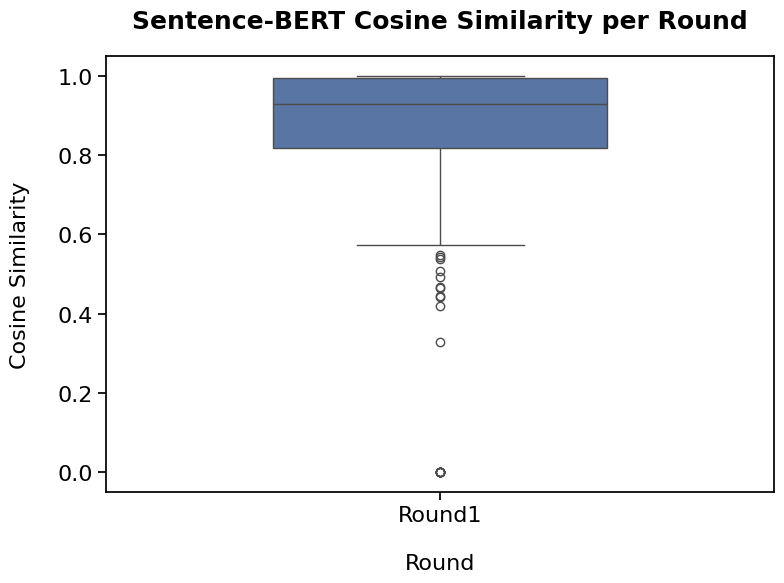

In [65]:
# Boxplots of similarity scores per round

rows = []
for rnd, scores in round_scores_all.items():
    for s in scores:
        rows.append({"Round": rnd, "Similarity": s})
df = pd.DataFrame(rows)

round_order = [r for r in ["Round1", "Round2", "Round3"] if r in df["Round"].unique()]
if not round_order:
    round_order = sorted(df["Round"].unique())

plt.figure()
ax = sns.boxplot(x="Round", y="Similarity", data=df, order=round_order, width=0.5)

ax.set_title("Sentence-BERT Cosine Similarity per Round")
ax.set_xlabel("Round")
ax.set_ylabel("Cosine Similarity")

plt.tight_layout()
plt.show()


The boxplot shows the distribution of Sentence-BERT cosine similarity scores between predicted and gold `TasksDescriptions` across all teams for each of the three rounds. In each round, the median similarity is very high (~0.95), and the interquartile range lies mostly above 0.8. This shows that most model task predictions are close matches to the gold standard. However, there are some outliers, with similarity scores below 0.5. These team members and their task descriptions will be looked at later.

Moreover, the three rounds have nearly identical distributions, so the model performance across rounds is similar.

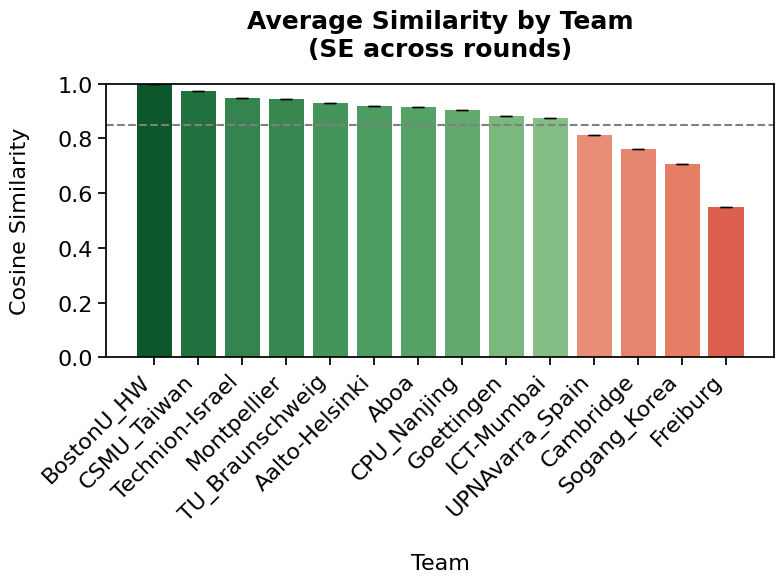

In [66]:
# Barplot per teams (average scores per round) with standard error calculated for teams between rounds
threshold = 0.85  # target dashed line 

rows = []
for team, rnds in team_round_scores.items():
    vals = [v for v in rnds.values() if isinstance(v, (int, float)) and not np.isnan(v)]
    if not vals:
        continue
    mean_team = float(np.mean(vals))
    if len(vals) > 1:
        se_team = float(np.std(vals, ddof=1) / math.sqrt(len(vals)))
    else:
        se_team = 0.0
    rows.append({"Team": str(team), "Mean": mean_team, "SE": se_team})

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No valid team scores found.")

# Sort by decreasing mean
df = df.sort_values("Mean", ascending=False).reset_index(drop=True)

greens = cm.Greens(np.linspace(0.4, 0.9, len(df)))  # shades of green
reds   = cm.Reds(np.linspace(0.4, 0.9, len(df)))    # shades of red

colors = []
for m in df["Mean"]:
    if m >= threshold:
        # scale within [threshold, 1]
        rel = (m - threshold) / (1 - threshold) if threshold < 1 else 0
        colors.append(cm.Greens(0.4 + 0.5 * rel))  # darker at threshold - lighter toward 1
    else:
        # scale within [0, threshold]
        rel = (threshold - m) / threshold if threshold > 0 else 0
        colors.append(cm.Reds(0.4 + 0.5 * rel))    # darker at threshold - lighter toward 0

# Plot 
ax = sns.barplot(
    x="Team", y="Mean", data=df,
    order=df["Team"].tolist(),
    errorbar=None,        
    hue="Team",           
    palette=dict(zip(df["Team"], colors)),
    legend=False         
)

# Error bars - SE between rounds for each team
xpos = np.arange(len(df))
plt.errorbar(
    xpos, df["Mean"].values, yerr=df["SE"].values,
    fmt="none", ecolor="black", elinewidth=1.2, capsize=4
)

ax.axhline(threshold, linestyle="--", linewidth=1.5, color="gray")

ax.set_title("Average Similarity by Team\n(SE across rounds)")
ax.set_xlabel("Team")
ax.set_ylabel("Cosine Similarity")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

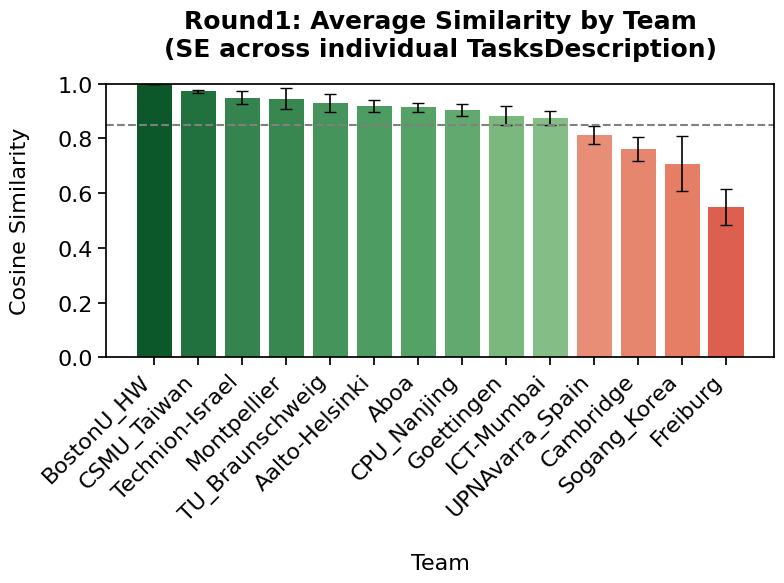

Round2: No data, skipping.
Round3: No data, skipping.


In [67]:
# Barplot per teams per round (average scores per team per round) with standard error calculated for teams between members within one round

threshold = 0.85
round_keys = ["Round1", "Round2", "Round3"]

for rk in round_keys:
    rows = []
    for team in sorted(team_round_scores.keys()):
        mean_val = team_round_scores.get(team, {}).get(rk, None)
        se_val   = team_round_errors.get(team, {}).get(rk, None)
        if mean_val is None or se_val is None or np.isnan(mean_val):
            continue
        rows.append({"Team": str(team), "Mean": float(mean_val), "SE": float(se_val)})

    df = pd.DataFrame(rows)
    if df.empty:
        print(f"{rk}: No data, skipping.")
        continue

    df = df.sort_values("Mean", ascending=False).reset_index(drop=True)

    colors = []
    for m in df["Mean"]:
        if m >= threshold:
            rel = (m - threshold) / (1 - threshold) if threshold < 1 else 0
            colors.append(cm.Greens(0.4 + 0.5 * rel))
        else:
            rel = (threshold - m) / threshold if threshold > 0 else 0
            colors.append(cm.Reds(0.4 + 0.5 * rel))

    # Plot
    ax = sns.barplot(
        x="Team", y="Mean", data=df,
        order=df["Team"].tolist(),
        errorbar=None,
        hue="Team",
        palette=dict(zip(df["Team"], colors)),
        legend=False
    )

    # Error bars
    xpos = np.arange(len(df))
    plt.errorbar(
        xpos, df["Mean"].values, yerr=df["SE"].values,
        fmt="none", ecolor="black", elinewidth=1.2, capsize=4
    )

    ax.axhline(threshold, linestyle="--", linewidth=1.5, color="gray")

    # Labels / style
    ax.set_title(f"{rk}: Average Similarity by Team\n(SE across individual TasksDescription)")
    ax.set_xlabel("Team")
    ax.set_ylabel("Cosine Similarity")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

The previous bar plots show a comparison of cosine similarities between teams. In the first plot, the error bars represent the standard error calculated between rounds for each team, while in the second set of plots the standard errors are calculated between individual `TasksDescription` items, per team and per round. The bar plot visualization helps illustrate which kinds of team attributions work, so that we can create a filter for teams whose attributions clearly will not work (e.g., when they are listed in tables).

For example, in the case of Sogang Korea, the errors calculated between individual members are large because some team members have their attributions listed in unreadable tables, while advisors and PIs have normally formulated attributions. The model does not perform well with tabular data alone. The differences in how teams formulate their attributions and how the model processes them should be further explored.

In [68]:
# Get Task desriptions with low similarity scores

# API call again so we can store task descriptions and their similarity scores in a dictionary (we did a list of floats previously because that was easier for plotting code)
load_dotenv(override=True) 
hf_token = os.getenv('HF_TOKEN')

API_URL = "https://router.huggingface.co/hf-inference/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/pipeline/sentence-similarity"
HEADERS = {
    "Authorization": f"Bearer {hf_token}"
}

# API call with retry and sleep 
def get_cosine_similarity(text1, text2, max_retries=3, delay=1.5):
    text1 = normalize_text(text1)
    text2 = normalize_text(text2)

    if not text1 and not text2:
        return 1.0
    if not text1 or not text2:
        return 0.0

    payload = {
        "inputs": {
            "source_sentence": text1,
            "sentences": [text2]
        }
    }

    for attempt in range(max_retries):
        try:
            response = requests.post(API_URL, headers=HEADERS, json=payload)
            if response.status_code == 200:
                result = response.json()
                if isinstance(result, list) and len(result) > 0:
                    return result[0]
                else:
                    print("Unexpected API result:", result)
                    return 0.0
            else:
                print(f"API error ({response.status_code}), retrying...")
        except Exception as e:
            print(f"Request failed: {e}")
        time.sleep(delay)

    print("Failed after retries")
    return 0.0

# Score containers 
round_scores_all = {}          # round_name - list of all member scores (all teams)
team_round_scores = {}         # team - round_name - avg team score
team_round_errors = {}         # team - round_name - standard error

# Print team per per round
print("Average Sentence-BERT Cosine Similarity per Team per Round:\n")

for team, rounds in model_outputs.items():
    if team not in gold_standard:
        continue

    print(f"Processing Team: {team}")
    gold_entries = gold_standard[team]
    gold_tasks = [normalize_text(m.get("TasksDescription", "")) for m in gold_entries]

    for round_name, predictions in rounds.items():
        round_scores = []

        for i, member in enumerate(predictions):
            pred_tasks = member.get("TasksDescription", "")
            gold_tasks_text = gold_tasks[i] if i < len(gold_tasks) else ""

            score = get_cosine_similarity(pred_tasks, gold_tasks_text)
            round_scores.append(score)

            # Save all member scores per round (for per-round analysis)
            # I am saving it in a dictionary so that we can extract task descriptions that have low similarity scores between gold and model outputs
            # If that is not needed, simpler code would be: round_scores_all.setdefault(round_name, []).append(score)
            round_scores_all.setdefault(round_name, []).append({
                "team": team,
                "pred": pred_tasks,
                "gold": gold_tasks_text,
                "score": score
            })

            time.sleep(1.5)  

        if round_scores:
            avg = mean(round_scores)
            se = compute_se(round_scores)

            team_round_scores.setdefault(team, {})[round_name] = avg
            team_round_errors.setdefault(team, {})[round_name] = se


# Print task descriptions with low similarity scores (< 0.5)
print("\nTask Descriptions with Low Similarity Scores (< 0.5):")
for rnd, items in round_scores_all.items():
    # Filter only dict entries (ignore old float-only if any)
    low_cases = [it for it in items if isinstance(it, dict) and it["score"] < 0.5]
    
    if low_cases:
        print(f"\nRound {rnd} — {len(low_cases)} low-similarity cases (< 0.5):")
        for case in low_cases:
            print(f"Team: {case['team']}")
            print(f"  Predicted: {case['pred']}")
            print(f"  Gold:      {case['gold']}")
            print(f"  Score:     {case['score']:.3f}")
            print("-" * 60)
    else:
        print(f"\nRound {rnd}: No low similarity score Task Descriptions found (Score < 0.5).")
        print("-" * 60)


Average Sentence-BERT Cosine Similarity per Team per Round:

Processing Team: Aalto-Helsinki
Processing Team: Aboa
Processing Team: BostonU_HW
Processing Team: Cambridge
Processing Team: CPU_Nanjing
Processing Team: CSMU_Taiwan
Processing Team: Freiburg
Processing Team: Goettingen
Processing Team: ICT-Mumbai
Processing Team: Montpellier
Processing Team: Sogang_Korea
Processing Team: Technion-Israel
Processing Team: TU_Braunschweig
Processing Team: UPNAvarra_Spain

Task Descriptions with Low Similarity Scores (< 0.5):

Round Round1 — 16 low-similarity cases (< 0.5):
Team: Cambridge
  Predicted: None
  Gold:      anthony's main roles included project ideation, wet-lab, modelling, circuit design, safety and wiki design.
  Score:     0.000
------------------------------------------------------------
Team: Freiburg
  Predicted: Compartments Modelling Fundraising
  Gold:      brainstorming to find and flesh out the project topic at the beginning researching literature on the topic making sur

The previous output contains TasksDescription values that have a low similarity score (<0.5) between the gold standard and the model output. Look into these mistakes to figure out what causes problems for the model (mostly attributions written in tables).